In [1]:
from fastai.vision.all import *

In [2]:
path = Path('dataset')

In [3]:
dls = ImageDataLoaders.from_folder(
    path=path,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(128), 
    batch_tfms=aug_transforms(),
    num_workers=0
)

['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


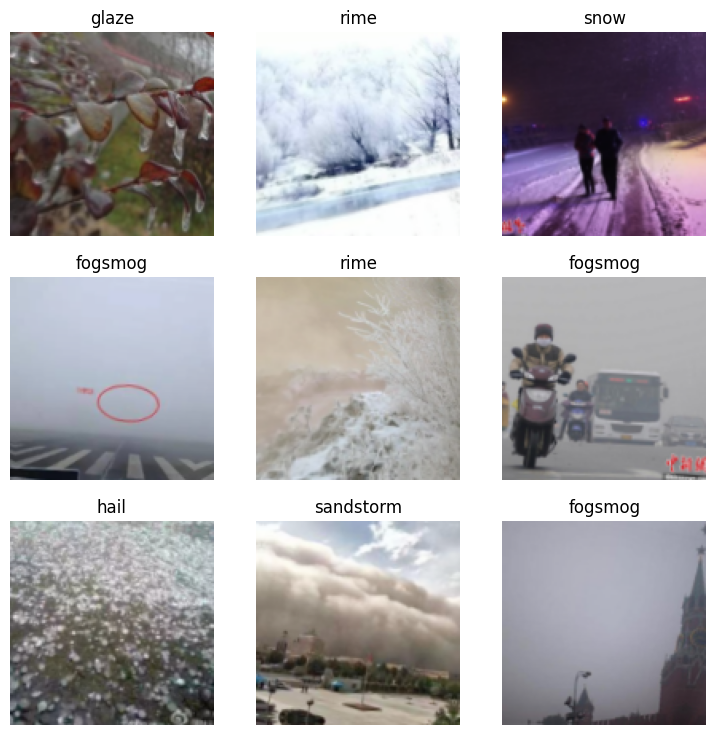

In [4]:
dls.show_batch()
print(dls.vocab)

In [5]:
learner = vision_learner(dls, resnet34, metrics=error_rate)
learner.fine_tune(5)

epoch,train_loss,valid_loss,error_rate,time
0,1.480864,0.720463,0.223032,00:33


epoch,train_loss,valid_loss,error_rate,time
0,0.741048,0.532094,0.147230,00:36
1,0.540056,0.460834,0.140671,00:36
2,0.375826,0.406458,0.109329,00:37
3,0.279031,0.356587,0.102041,00:37
4,0.210454,0.349455,0.102041,00:36


In [6]:
learner.fit_one_cycle(3, lr_max=1e-5)

epoch,train_loss,valid_loss,error_rate,time
0,0.180394,0.342943,0.102770,00:36
1,0.178541,0.341715,0.100583,00:36
2,0.157188,0.348122,0.100583,00:35


In [10]:
import shutil
learner.export('weather_classifier.pkl')
shutil.move('dataset/weather_classifier.pkl', 'weather_classifier.pkl')

'weather_classifier.pkl'

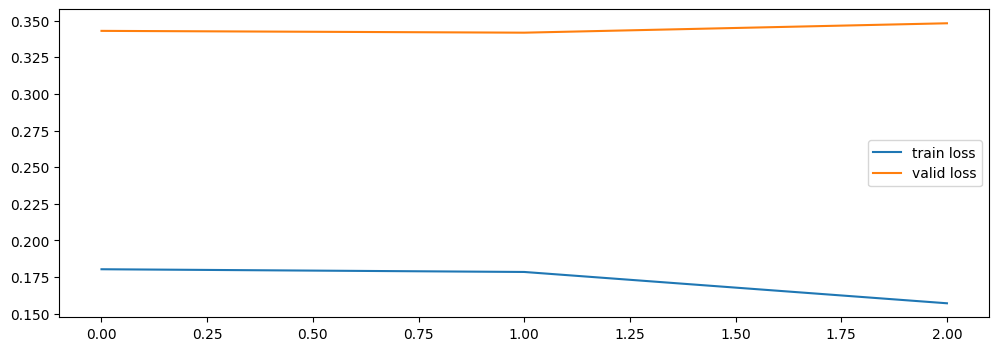

In [8]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))
learner_metrics = learner.recorder.values
learner_loss =[row[0] for row in learner_metrics]
learner_valid =[row[1] for row in learner_metrics]

ax1.plot(learner_loss, label='train loss')
ax1.plot(learner_valid, label='valid loss')
ax1.legend()
plt.show()

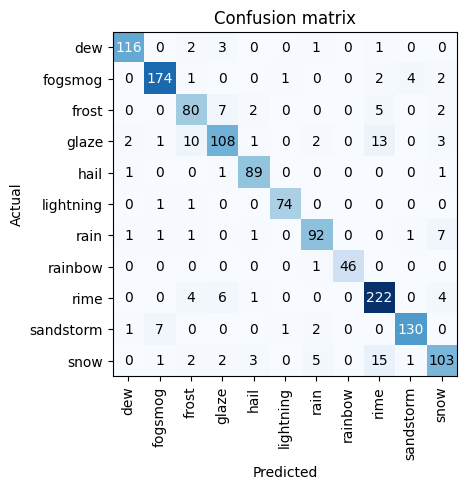

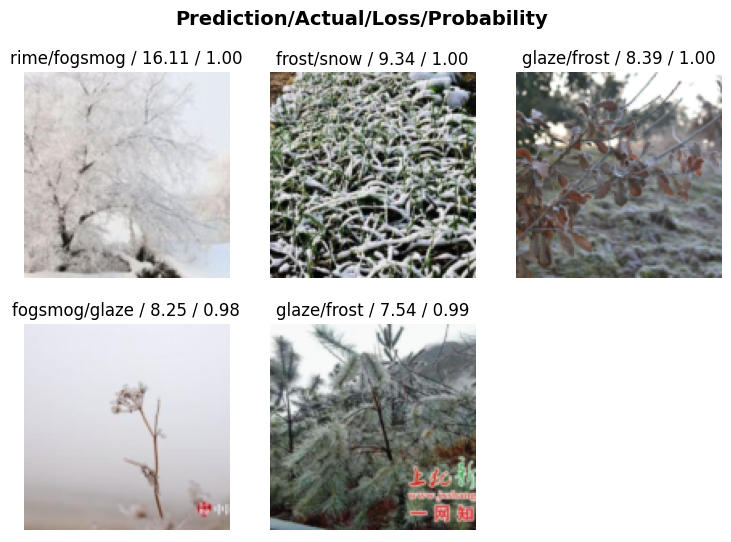

In [11]:
interp = ClassificationInterpretation.from_learner(learner)
interp.plot_confusion_matrix()
interp.plot_top_losses(5)

#   Write down why you think it's making those specific mistakes:
## So from my point of view, the model confused these classes with specifically those other classes due to the fact that they DO look similar even to a human eye, let alone a model. So that looks justifiable to me.
